In [1]:
# Wavefunction generation
from pyscf import mcscf, fci, lib 
from pyscf import gto, scf, tools, dft
import api as pyq 
import importlib
import os
import h5py
import pandas as pd
import pdb
import pyscf
import numpy as np
import pyqmc
import scipy
import copy
import gpu
import matplotlib.pyplot as plt
from pyscf.scf.hf import dump_scf_summary
from concurrent.futures import ProcessPoolExecutor
from pyscf.scf.chkfile import dump_scf
print(pyq.__file__)
print(pyscf.__file__)

/Users/ksu/Documents/GitHub/pyqmc/pyqmc/api.py
/Users/ksu/Software/anaconda3/lib/python3.11/site-packages/pyscf/__init__.py


In [2]:
# Wavefunction generation
from scf_runs import run_lda_h2, run_casci
scf_chkfile, _, mf_lda = run_lda_h2()
ci_chkfile, mcc, opt_chkfile, vmc_chkfile = run_casci(scf_chkfile, nroots=2, ncas = 1)
opt_chkfile = 'ab_' + opt_chkfile
vmc_chkfile = 'ab_' + vmc_chkfile

/Users/ksu/Documents/GitHub/pyqmc/pyqmc/api.py
/Users/ksu/Software/anaconda3/lib/python3.11/site-packages/pyscf/__init__.py
H2 molecule neutral LDA spin=0
converged SCF energy = -0.98122642479507  <S^2> = 4.4408921e-16  2S+1 = 1
CASCI nelecas up/down (1, 1)

WARN: Mulitple states found in CASCI solver. First state is used to compute the Fock matrix and natural orbitals in active space.

CASCI state   0  E = -1.08269538779884  E(CI) = -2.08269538779884  S^2 = 0.0000000
Available output from CASCI: <KeysViewHDF5 ['ci', 'fci', 'mc_mo_energy', 'mf_mo_energy', 'mo_coeff', 'mo_occ', 'ncas', 'ncore', 'nelecas']>


In [3]:
import importlib, bosonrecipes, mc, bosonslater
modules = [bosonrecipes, mc, bosonslater]
for m in modules:
    importlib.reload(m)

for fname in [opt_chkfile]:
    if os.path.isfile(fname):
        os.remove(fname)
jastrow_kws = {"ion_cusp":False, "na":0, "nb": 3}
wf, df = bosonrecipes.ABOPTIMIZE(
                        scf_chkfile, 
                         opt_chkfile,
                         nconfig=1000, 
                          max_iterations=5,
                         ci_checkfile=ci_chkfile,
                         jastrow_kws = jastrow_kws,
                         # det_emax = 1,
                         verbose = True,)

Used # of determinants 1
Using spherical guess
starting warmup
finished warmup
Pgrad acc type:  <class 'boson_stochastic_reconfiguration.BosonStochasticReconfiguration'>
Pgrad enacc type:  <class 'bosonaccumulators.ABQMCEnergyAccumulator'>
Pgrad transform type:  <class 'accumulators.LinearTransform'>
0 params [0. 0. 0. 0. 0. 0. 0. 0. 0.]
--0.007971130120321265 -0.013646037220730768 0.5985936566691278 2.649540273982337 -0.8280885379785476 -0.7462233975553982 -3.498033717372411 1.0 -0.9906986442311119
--0.008352352511643431 -0.015293282103173591 0.6291434307122017 2.741236025411702 -0.8714291749530407 -0.7462233975553982 -3.7322728894685633 1.0 -1.0105324519166747
--0.011864489390286372 -0.016140172874144033 0.6614147668788257 2.7723404877423903 -0.8864106478414656 -0.7462233975553982 -3.838691172676451 1.0 -0.9987431328419277
--0.021561407455413354 -0.016123006886395435 0.6860668434151888 2.793197501522346 -0.897161807273502 -0.7462233975553982 -3.934273890980836 1.0 -0.9938766627308625

In [4]:
import importlib, bosonrecipes, bosondmc, bosonaccumulators, mc, bosonenergy
modules = [bosonrecipes, bosondmc, bosonaccumulators, mc, bosonenergy]
for m in modules:
    importlib.reload(m)

for fname in [vmc_chkfile]:
    if os.path.isfile(fname):
        os.remove(fname)
        

bosonrecipes.ABVMC(
                   scf_chkfile, 
                   vmc_chkfile,
                   nconfig=1000, 
                   nblocks = 100,
                   load_parameters = opt_chkfile, 
                   ci_checkfile=ci_chkfile,
                   jastrow_kws     = jastrow_kws,
                   verbose = False,
                  )



Used # of determinants 1
Using spherical guess
-0.04801976255002711 -0.06042821014812458 0.5869716165338875 2.5847081583105074 -0.798070441184966 -0.7462233975553982 -3.356169872108422 1.0 -1.0543374708452034
-0.06287201014297314 -0.06453577563539872 0.6199673538562729 2.6624491784269577 -0.8352221193528485 -0.7462233975553982 -3.576564618688521 1.0 -1.0808908885516069
-0.060408214582909826 -0.06969668227039441 0.6321616193171267 2.725497257529939 -0.8662030616756239 -0.7462233975553982 -3.7753973572815736 1.0 -1.1034608709458902
-0.04822410174136546 -0.07319743856418433 0.6185169016065479 2.762654059092444 -0.8837193992865907 -0.7462233975553982 -3.8881321641143973 1.0 -1.1280626960602542
-0.061326100527695646 -0.07326980711994067 0.6327391319846634 2.77973824271891 -0.8919463199854705 -0.7462233975553982 -3.9500111418582065 1.0 -1.1358720959518105
-0.060852370519608553 -0.07374677206473948 0.6409343609705836 2.777383472939563 -0.8900025563666861 -0.7462233975553982 -3.924376609349184

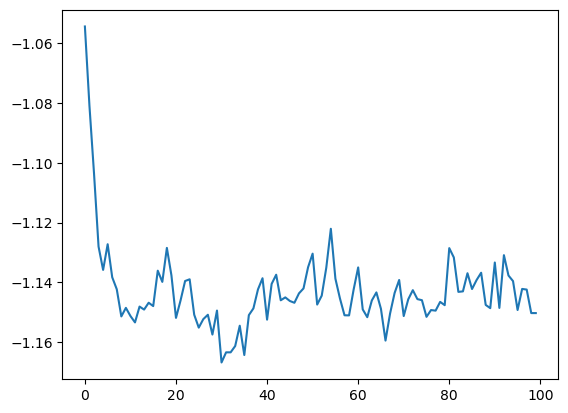

In [5]:
import h5py
f = h5py.File(vmc_chkfile, "r")
f.keys()
plt.plot(np.array(f['energytotal']))
f.close()

In [6]:
import importlib, bosonrecipes, bosondmc, bosonaccumulators, mc, bosonenergy
modules = [bosonrecipes, bosondmc, bosonaccumulators, mc, bosonenergy]

for m in modules:
    importlib.reload(m)

dmc_chkfile = 'abdmc_out.hdf5'
for fname in [dmc_chkfile]:
    if os.path.isfile(fname):
        os.remove(fname)

bosonrecipes.ABDMC(
                    scf_chkfile, 
                    dmc_chkfile,
                    nconfig=1000, 
                    nblocks = 100,
                    vmc_warmup = 1,
                    jastrow_kws = jastrow_kws,
                    load_parameters = opt_chkfile, 
                    ci_checkfile=ci_chkfile,
                    verbose = True,
)

Used # of determinants 1
Using spherical guess
--0.04037459726003396 -0.05707394144139845 0.5647918237022155 2.5365339428081497 -0.7758420105120102 -0.7462233975553982 -3.2223280111526775 1.0 -1.0395720448507546
vmc done
-0.04037459726003396 -0.05707394144139845 0.5647918237022155 2.5365339428081497 -0.7758420105120102 -0.7462233975553982 -3.2223280111526775 1.0 -1.0395720448507546
eref start -1.0395720448507546 esigma 0.27132025875606
-0.04037459726003396 -0.05707394144139845 0.5647918237022155 2.5365339428081497 -0.7758420105120102 -0.7462233975553982 -3.2223280111526775 1.0 -1.0395720448507546
-0.04180927523850737 -0.058093242997017625 0.5671310281719077 2.5449371976209925 -0.7801255719879603 -0.7462233975553982 -3.2508611160561394 1.0 -1.0438065132520478
-0.04009217841205728 -0.05799125689015244 0.5641169464776856 2.5461969989731084 -0.7810832439490805 -0.7462233975553982 -3.2814898858376864 1.0 -1.0453036414039498
-0.037531128910514674 -0.057733014119374794 0.5608714183950231 2.54

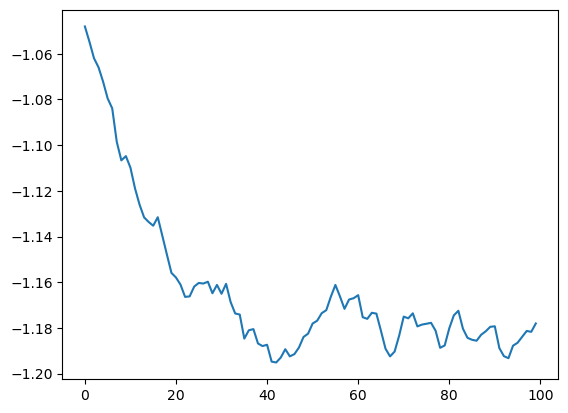

In [7]:
import h5py
f = h5py.File(dmc_chkfile, "r")
f.keys()
plt.plot(np.array(f['energytotal']))
f.close()